In [27]:
# -*- coding: utf-8 -*-

"""
Script para visualizar imágenes hiperespectrales de reflectancia.
Usa spectral.imshow() para una visualización clara y especializada.
"""

# Librerías
from spectral import imshow, save_rgb
import spectral.io.envi as envi
import numpy as np
from os import getcwd, makedirs

# Directorio actual y carpeta de salida
wd = getcwd()
makedirs('Fig', exist_ok=True)

# Leer imagen hiperespectral, el envi.open() devuelve un objeto tipo spectral.image que representa el cubo 3d (alto x ancho x bandas espectrales)
def visualize_hdr_dat(datfile,hdrfile):
    reflectance_img = envi.open(
        hdrfile,
        datfile
    )


    # Mostrar metadatos disponibles
    print("Metadatos encontrados:")
    print(reflectance_img.metadata.keys())

    # Obtener las bandas RGB por defecto desde el encabezado
    rgb_bands = [int(b) for b in reflectance_img.metadata['default bands']]
    # #[100,80,40]
    # # Mostrar imagen RGB con bandas por defecto
    imshow(reflectance_img, rgb_bands)
    # # Guardar RGB como imagen si lo deseas
    # save_rgb('Fig/imreflectance_rgb.png', reflectance_img, bands=rgb_bands)

    # # Zoom en una región de la imagen (hoja)
    imZoom = reflectance_img[150:200, 150:200, :]
    #imZoom = reflectance_img[50:100, 50:100, :]
    #imZoom = reflectance_img[25:75, 25:75, :]

    imshow(imZoom, rgb_bands)
    ## No se puede guardar directamente el zoom con save_rgb a menos que se cree una imagen falsa

    # # Obtener espectros de la subimagen para graficar
    sp = np.reshape(imZoom, (50 * 50, reflectance_img.shape[2]))
    lbds = [float(x) for x in reflectance_img.metadata['wavelength']]

    print(len(reflectance_img.metadata['wavelength']))
    # Mostrar los espectros de los primeros 71 píxeles
    import matplotlib.pyplot as plt
    plt.figure()
    for i in range(71):
        plt.plot(lbds, sp[i, :])
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Reflectance')
    plt.title('Spectra of the subimage')
    plt.savefig('Fig/spectra.pdf')

    # Análisis de componentes principales (SVD)
    sp_centered = sp - sp.mean(axis=0)
    U, s, V = np.linalg.svd(sp_centered)

    # Obtener las primeras 4 componentes principales
    pcs = [V.T[:, i] for i in range(4)]
    titles = ['PC1', 'PC2', 'PC3', 'PC4']

    # Graficar las cargas de cada componente
    for i, pc in enumerate(pcs):
        plt.figure()
        plt.plot(lbds, pc)
        plt.axhline(color='gray', linestyle='--')
        plt.xlabel('Wavelength (nm)')
        plt.ylabel('Loadings')
        plt.title(f'Loadings for {titles[i]}')
        plt.savefig(f'Fig/{titles[i].lower()}.pdf')

    # Calcular scores para PC1-PC4
    scores = [sp_centered.dot(pc) for pc in pcs]
    xilX = np.tile(np.arange(0, 50, 1), 50)
    xilY = np.sort(xilX)

    # Graficar combinaciones de scores
    plt.figure()
    plt.scatter(scores[0], scores[1], s=xilX, c=xilY)
    plt.axhline(color='gray', linestyle='--')
    plt.axvline(color='gray', linestyle='--')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.savefig('Fig/sc12.pdf')

    plt.figure()
    plt.scatter(scores[2], scores[3], s=xilX, c=xilY)
    plt.axhline(color='gray', linestyle='--')
    plt.axvline(color='gray', linestyle='--')
    plt.xlabel('PC3')
    plt.ylabel('PC4')
    plt.savefig('Fig/sc34.pdf')

# #input("Presiona ENTER para cerrar las ventanas...")


In [26]:
# -*- coding: utf-8 -*-

"""
Script para visualizar imágenes hiperespectrales de reflectancia.
Usa spectral.imshow() para una visualización clara y especializada.
"""

# Librerías
from spectral import imshow, save_rgb
import spectral.io.envi as envi
import numpy as np
from os import getcwd, makedirs

# Directorio actual y carpeta de salida
wd = getcwd()
makedirs('Fig', exist_ok=True)

# Leer imagen hiperespectral, el envi.open() devuelve un objeto tipo spectral.image que representa el cubo 3d (alto x ancho x bandas espectrales)
def visualize_hdr_dat_ds2(datfile,hdrfile):
    reflectance_img = envi.open(
        hdrfile,
        datfile
    )


    # Mostrar metadatos disponibles
    print("Metadatos encontrados:")
    print(reflectance_img.metadata.keys())

    # Obtener las bandas RGB por defecto desde el encabezado
    rgb_bands = [int(b) for b in reflectance_img.metadata['default bands']]
    # #[100,80,40]
    # # Mostrar imagen RGB con bandas por defecto
    imshow(reflectance_img, rgb_bands)
    # # Guardar RGB como imagen si lo deseas
    # save_rgb('Fig/imreflectance_rgb.png', reflectance_img, bands=rgb_bands)

    # # Zoom en una región de la imagen (hoja)
    #imZoom = reflectance_img[150:200, 150:200, :]
    imZoom = reflectance_img[50:100, 50:100, :]
    #imZoom = reflectance_img[25:75, 25:75, :]

    imshow(imZoom, rgb_bands)
    ## No se puede guardar directamente el zoom con save_rgb a menos que se cree una imagen falsa

    # # Obtener espectros de la subimagen para graficar
    sp = np.reshape(imZoom, (50 * 50, reflectance_img.shape[2]))
    lbds = [float(x) for x in reflectance_img.metadata['wavelength']]

    print(len(reflectance_img.metadata['wavelength']))
    # Mostrar los espectros de los primeros 71 píxeles
    import matplotlib.pyplot as plt
    plt.figure()
    for i in range(71):
        plt.plot(lbds, sp[i, :])
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Reflectance')
    plt.title('Spectra of the subimage')
    plt.savefig('Fig/spectra.pdf')

    # Análisis de componentes principales (SVD)
    sp_centered = sp - sp.mean(axis=0)
    U, s, V = np.linalg.svd(sp_centered)

    # Obtener las primeras 4 componentes principales
    pcs = [V.T[:, i] for i in range(4)]
    titles = ['PC1', 'PC2', 'PC3', 'PC4']

    # Graficar las cargas de cada componente
    for i, pc in enumerate(pcs):
        plt.figure()
        plt.plot(lbds, pc)
        plt.axhline(color='gray', linestyle='--')
        plt.xlabel('Wavelength (nm)')
        plt.ylabel('Loadings')
        plt.title(f'Loadings for {titles[i]}')
        plt.savefig(f'Fig/{titles[i].lower()}.pdf')

    # Calcular scores para PC1-PC4
    scores = [sp_centered.dot(pc) for pc in pcs]
    xilX = np.tile(np.arange(0, 50, 1), 50)
    xilY = np.sort(xilX)

    # Graficar combinaciones de scores
    plt.figure()
    plt.scatter(scores[0], scores[1], s=xilX, c=xilY)
    plt.axhline(color='gray', linestyle='--')
    plt.axvline(color='gray', linestyle='--')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.savefig('Fig/sc12.pdf')

    plt.figure()
    plt.scatter(scores[2], scores[3], s=xilX, c=xilY)
    plt.axhline(color='gray', linestyle='--')
    plt.axvline(color='gray', linestyle='--')
    plt.xlabel('PC3')
    plt.ylabel('PC4')
    plt.savefig('Fig/sc34.pdf')

# #input("Presiona ENTER para cerrar las ventanas...")

In [ ]:
# -*- coding: utf-8 -*-

"""
Script para visualizar imágenes hiperespectrales de reflectancia.
Usa spectral.imshow() para una visualización clara y especializada.
"""

# Librerías
from spectral import imshow, save_rgb
import spectral.io.envi as envi
import numpy as np
from os import getcwd, makedirs

# Directorio actual y carpeta de salida
wd = getcwd()
makedirs('Fig', exist_ok=True)

# Leer imagen hiperespectral, el envi.open() devuelve un objeto tipo spectral.image que representa el cubo 3d (alto x ancho x bandas espectrales)
def visualize_hdr_dat_ds4(datfile,hdrfile):
    reflectance_img = envi.open(
        hdrfile,
        datfile
    )


    # Mostrar metadatos disponibles
    print("Metadatos encontrados:")
    print(reflectance_img.metadata.keys())

    # Obtener las bandas RGB por defecto desde el encabezado
    rgb_bands = [int(b) for b in reflectance_img.metadata['default bands']]
    # #[100,80,40]
    # # Mostrar imagen RGB con bandas por defecto
    imshow(reflectance_img, rgb_bands)
    # # Guardar RGB como imagen si lo deseas
    # save_rgb('Fig/imreflectance_rgb.png', reflectance_img, bands=rgb_bands)

    # # Zoom en una región de la imagen (hoja)
    #imZoom = reflectance_img[150:200, 150:200, :]
    #imZoom = reflectance_img[50:100, 50:100, :]
    imZoom = reflectance_img[25:75, 25:75, :]

    imshow(imZoom, rgb_bands)
    ## No se puede guardar directamente el zoom con save_rgb a menos que se cree una imagen falsa

    # # Obtener espectros de la subimagen para graficar
    sp = np.reshape(imZoom, (50 * 50, reflectance_img.shape[2]))
    lbds = [float(x) for x in reflectance_img.metadata['wavelength']]

    print(len(reflectance_img.metadata['wavelength']))
    # Mostrar los espectros de los primeros 71 píxeles
    import matplotlib.pyplot as plt
    for i in range(71):
        plt.plot(lbds, sp[i, :])
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Reflectance')
    plt.title('Spectra of the subimage')
    plt.savefig('Fig/spectra.pdf')

    # Análisis de componentes principales (SVD)
    sp_centered = sp - sp.mean(axis=0)
    U, s, V = np.linalg.svd(sp_centered)

    # Obtener las primeras 4 componentes principales
    pcs = [V.T[:, i] for i in range(4)]
    titles = ['PC1', 'PC2', 'PC3', 'PC4']

    # Graficar las cargas de cada componente
    for i, pc in enumerate(pcs):
        plt.figure()
        plt.plot(lbds, pc)
        plt.axhline(color='gray', linestyle='--')
        plt.xlabel('Wavelength (nm)')
        plt.ylabel('Loadings')
        plt.title(f'Loadings for {titles[i]}')
        plt.savefig(f'Fig/{titles[i].lower()}.pdf')

    # Calcular scores para PC1-PC4
    scores = [sp_centered.dot(pc) for pc in pcs]
    xilX = np.tile(np.arange(0, 50, 1), 50)
    xilY = np.sort(xilX)

    # Graficar combinaciones de scores
    plt.figure()
    plt.scatter(scores[0], scores[1], s=xilX, c=xilY)
    plt.axhline(color='gray', linestyle='--')
    plt.axvline(color='gray', linestyle='--')
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.savefig('Fig/sc12.pdf')

    plt.figure()
    plt.scatter(scores[2], scores[3], s=xilX, c=xilY)
    plt.axhline(color='gray', linestyle='--')
    plt.axvline(color='gray', linestyle='--')
    plt.xlabel('PC3')
    plt.ylabel('PC4')
    plt.savefig('Fig/sc34.pdf')




### Datos Originales

Metadatos encontrados:
dict_keys(['description', 'samples', 'lines', 'bands', 'header offset', 'file type', 'data type', 'interleave', 'sensor type', 'byte order', 'default bands', 'latitude', 'longitude', 'acquisition date', 'errors', 'binning', 'tint', 'fps', 'wavelength'])
204


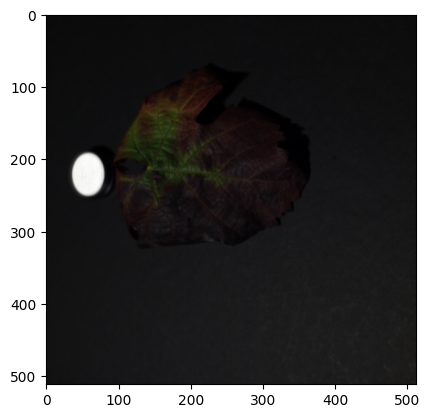

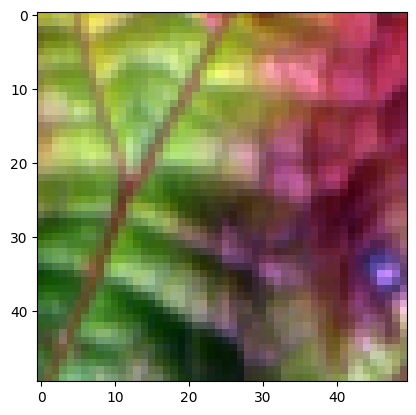

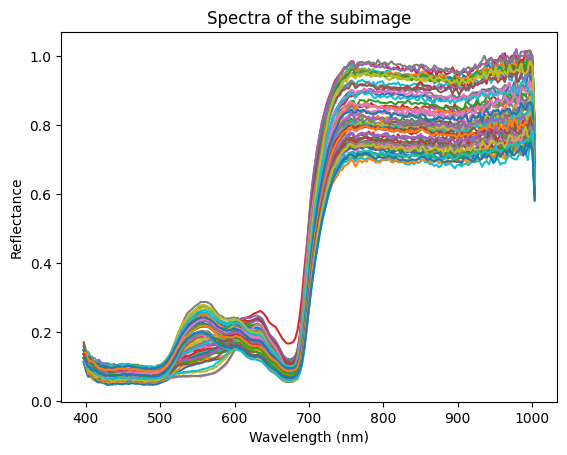

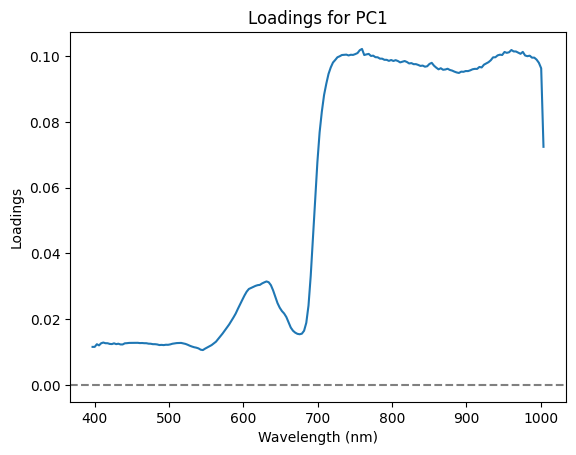

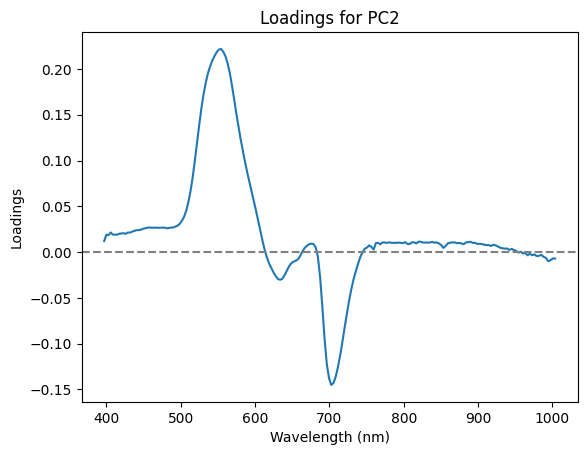

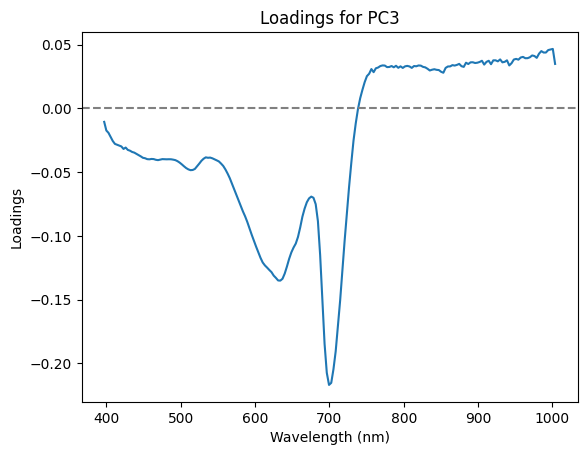

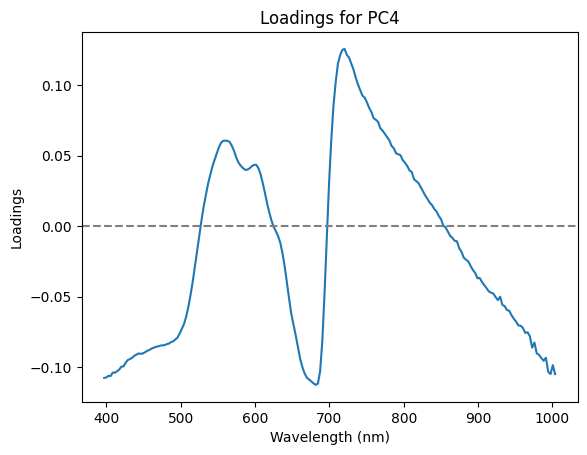

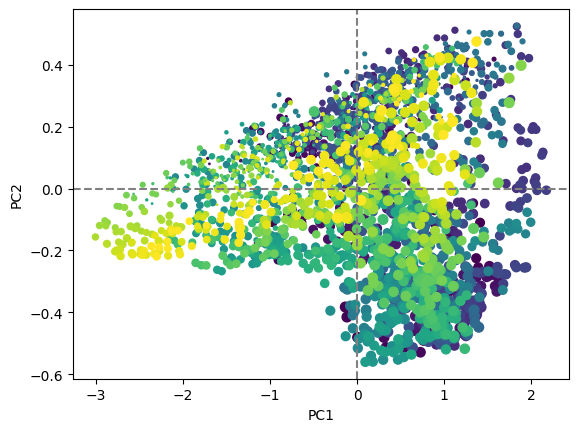

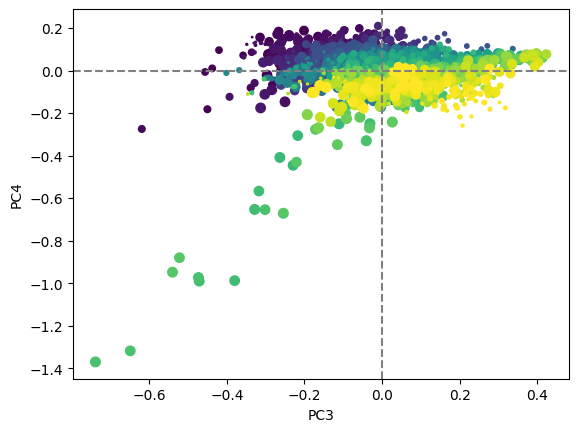

In [18]:
visualize_hdr_dat("/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/REFLECTANCE_2020-09-10_005.dat",
                  "/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/REFLECTANCE_2020-09-10_005.hdr")

Metadatos encontrados:
dict_keys(['description', 'samples', 'lines', 'bands', 'header offset', 'file type', 'data type', 'interleave', 'sensor type', 'byte order', 'default bands', 'latitude', 'longitude', 'acquisition date', 'errors', 'binning', 'tint', 'fps', 'wavelength'])


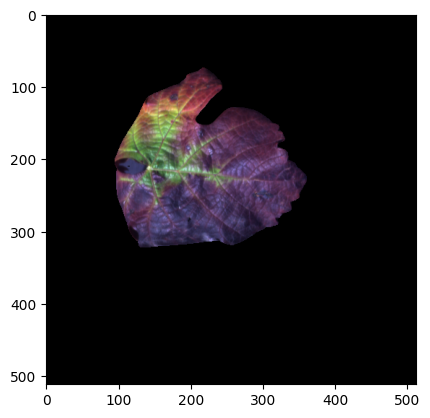

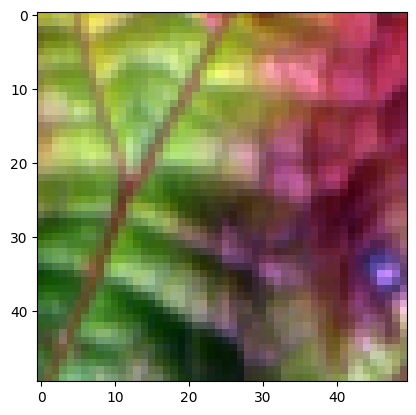

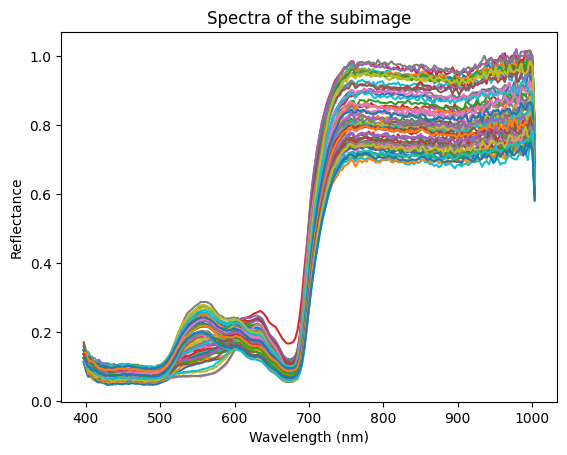

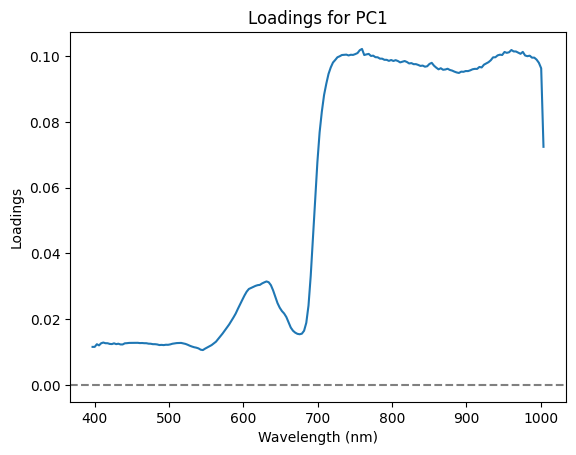

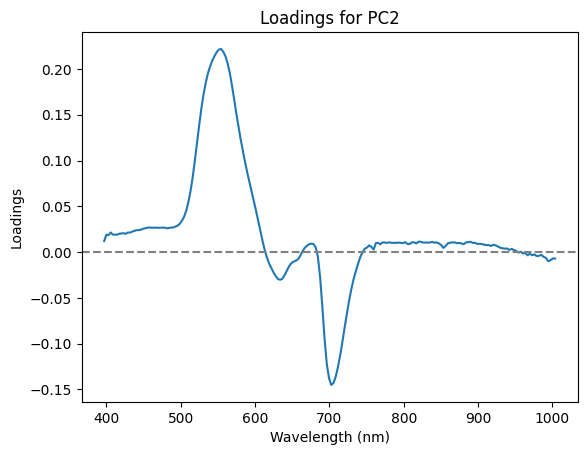

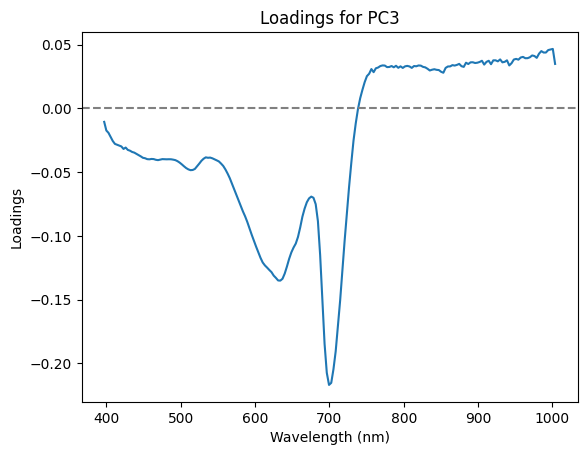

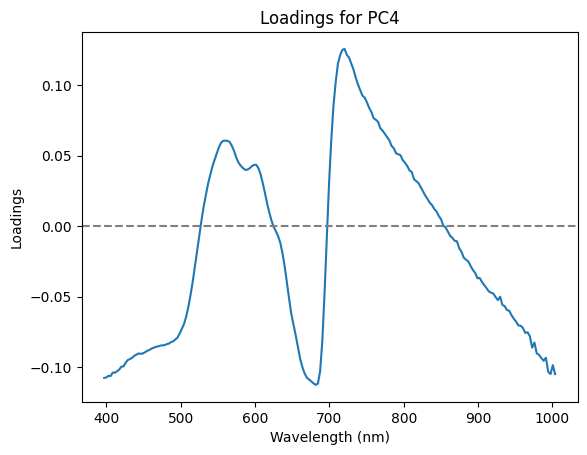

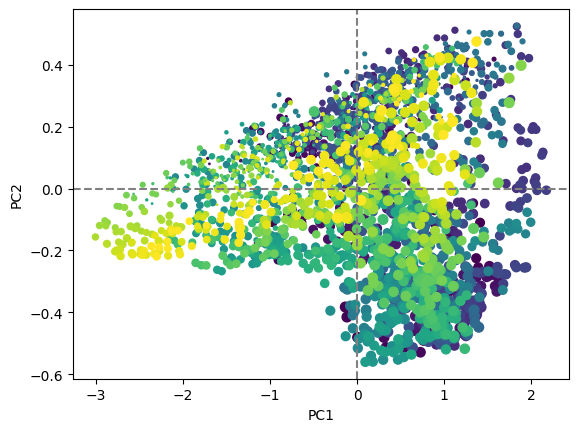

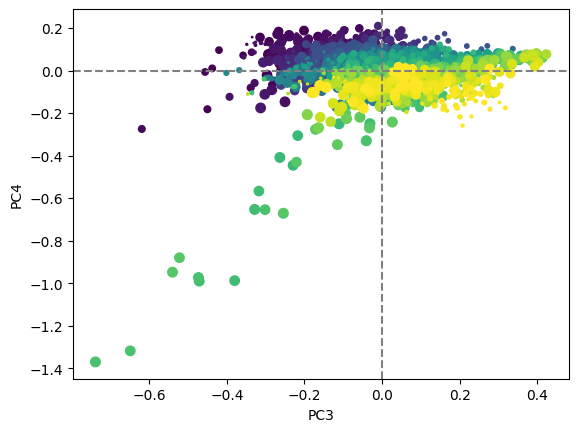

In [13]:
visualize_hdr_dat("/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked.dat",
                  "/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked.hdr")


Metadatos encontrados:
dict_keys(['description', 'samples', 'lines', 'bands', 'header offset', 'file type', 'data type', 'interleave', 'sensor type', 'byte order', 'default bands', 'latitude', 'longitude', 'acquisition date', 'errors', 'binning', 'tint', 'fps', 'wavelength'])


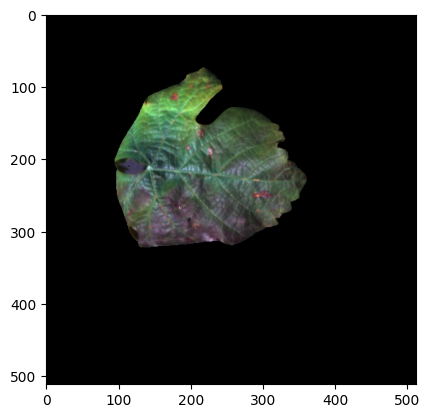

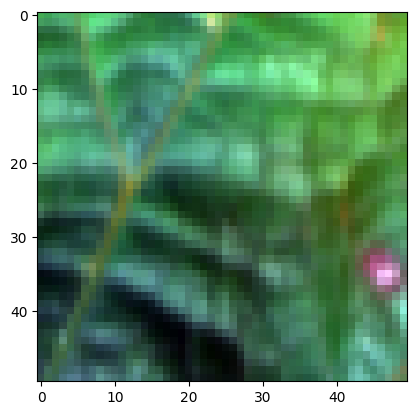

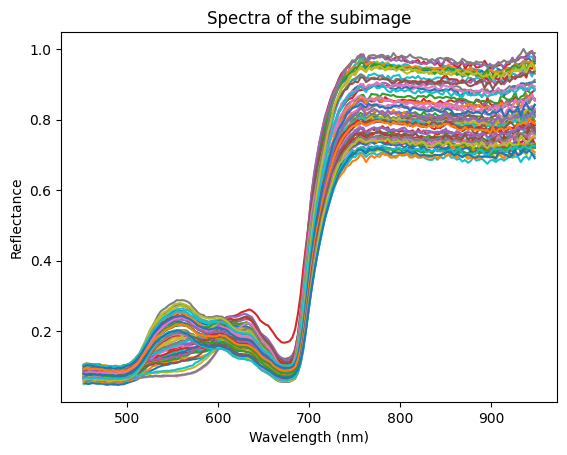

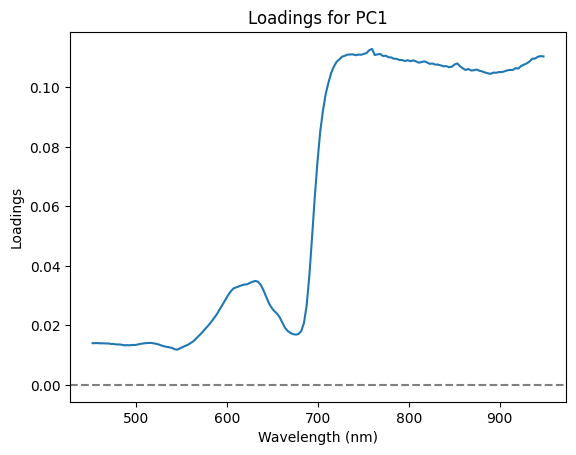

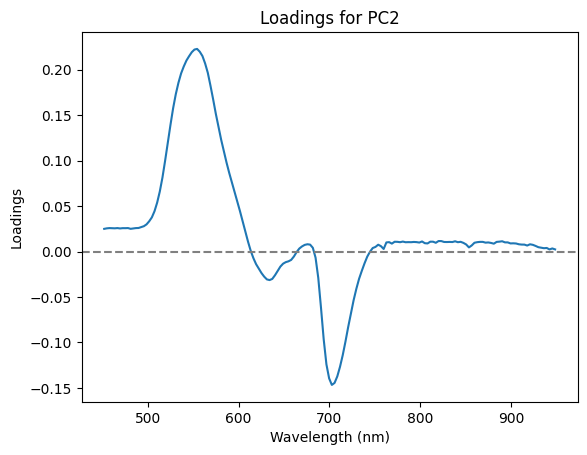

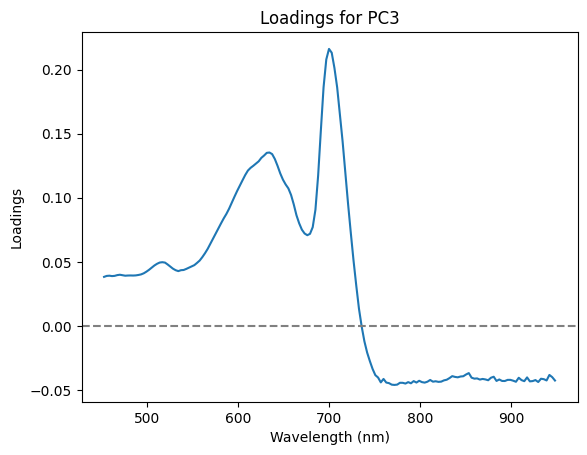

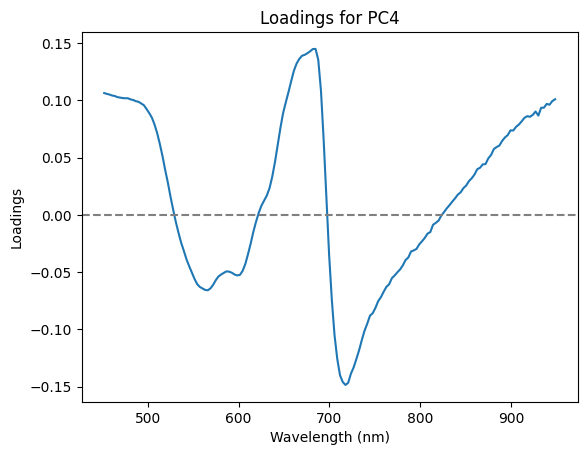

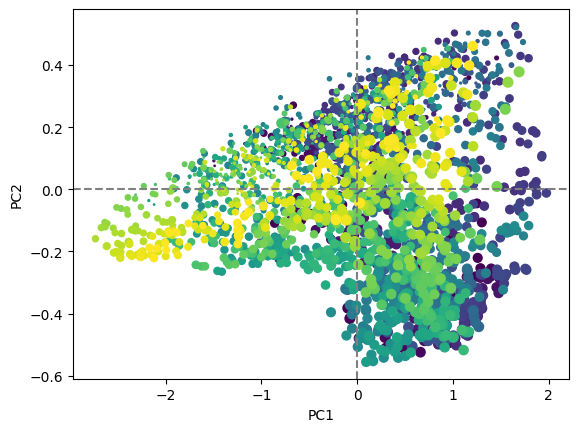

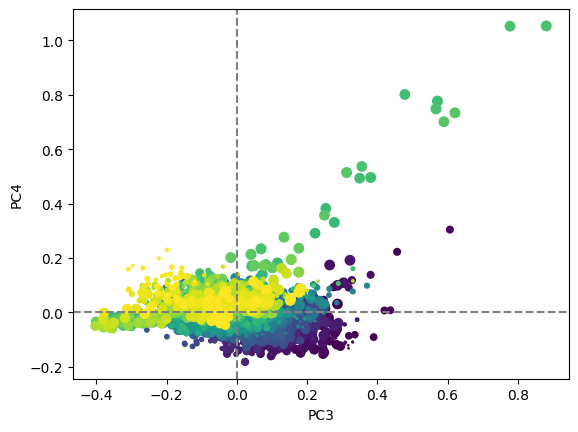

In [14]:
visualize_hdr_dat("/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked_trim450-950.dat",
                  "/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked_trim450-950.hdr")

Metadatos encontrados:
dict_keys(['description', 'samples', 'lines', 'bands', 'header offset', 'file type', 'data type', 'interleave', 'sensor type', 'byte order', 'default bands', 'latitude', 'longitude', 'acquisition date', 'errors', 'binning', 'tint', 'fps', 'wavelength'])
183


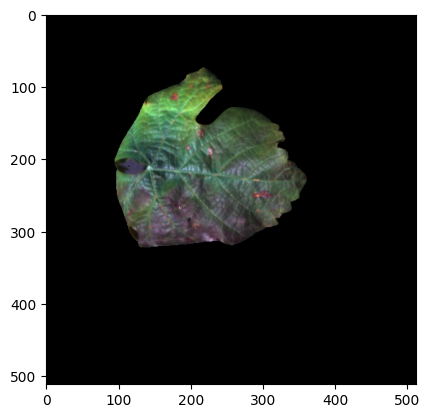

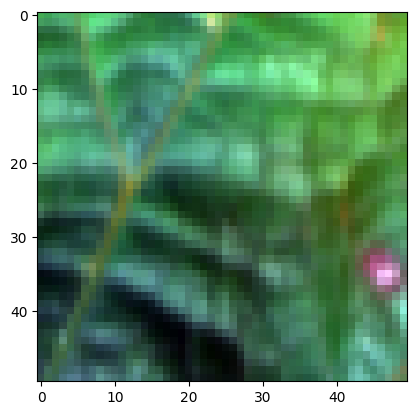

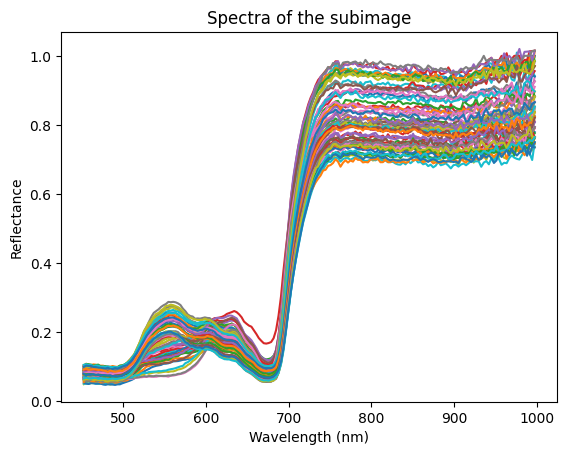

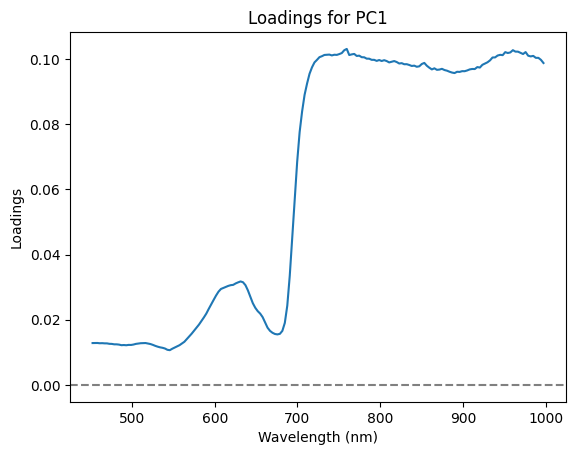

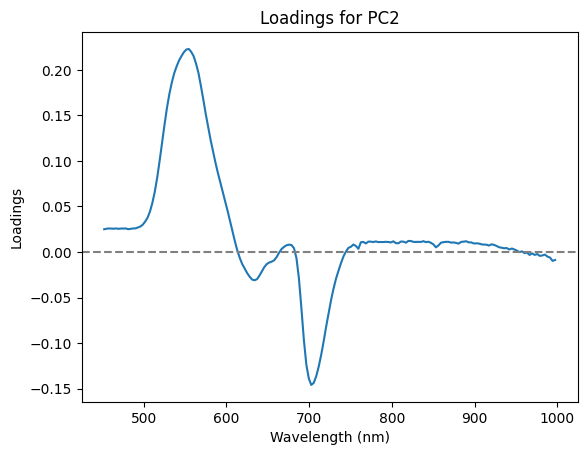

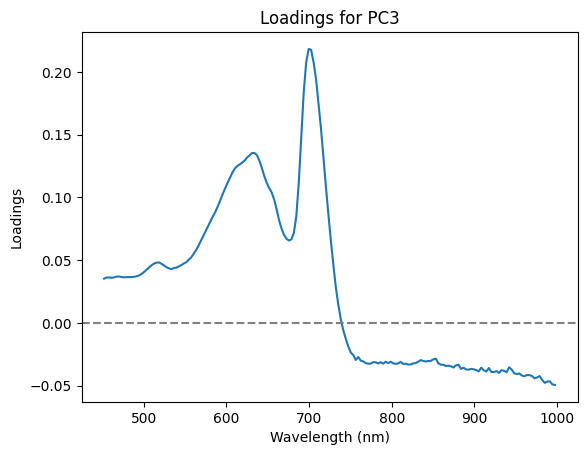

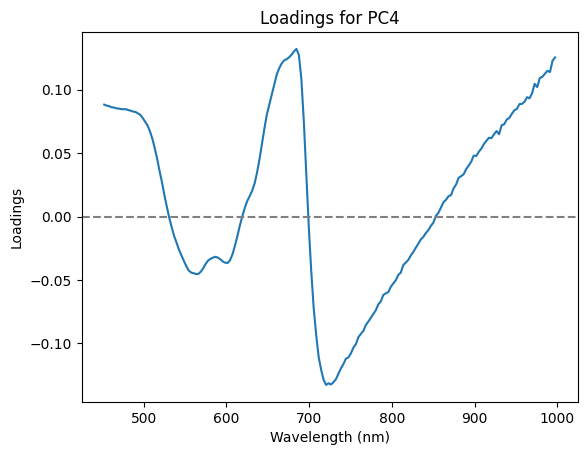

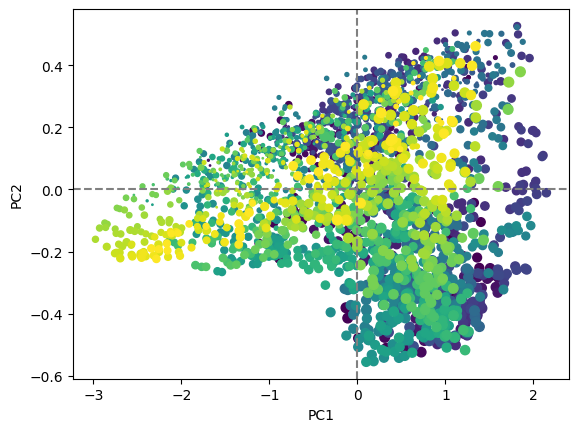

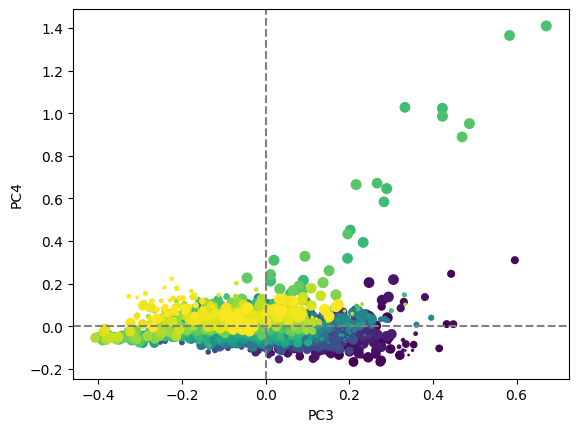

In [19]:
visualize_hdr_dat("/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked_trim450-1000.dat",
                  "/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked_trim450-1000.hdr")

Metadatos encontrados:
dict_keys(['description', 'samples', 'lines', 'bands', 'header offset', 'file type', 'data type', 'interleave', 'sensor type', 'byte order', 'default bands', 'latitude', 'longitude', 'acquisition date', 'errors', 'binning', 'tint', 'fps', 'wavelength'])
185


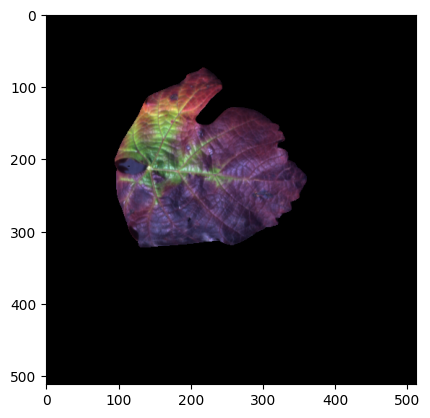

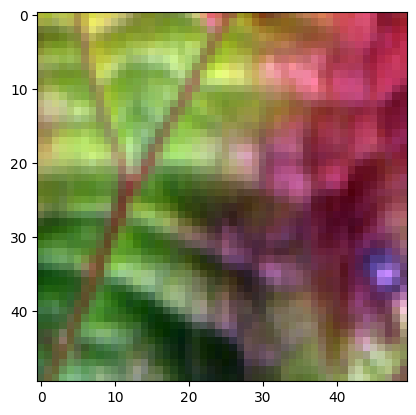

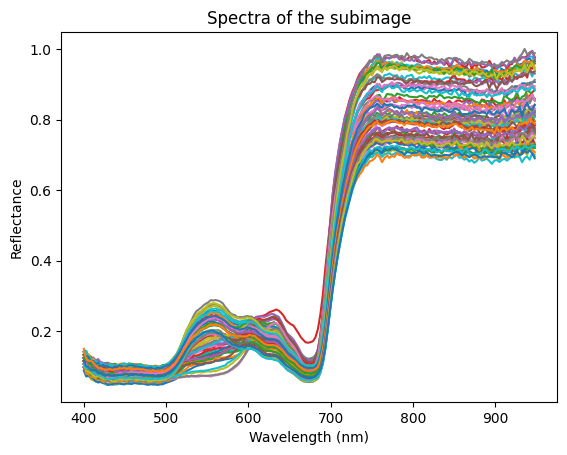

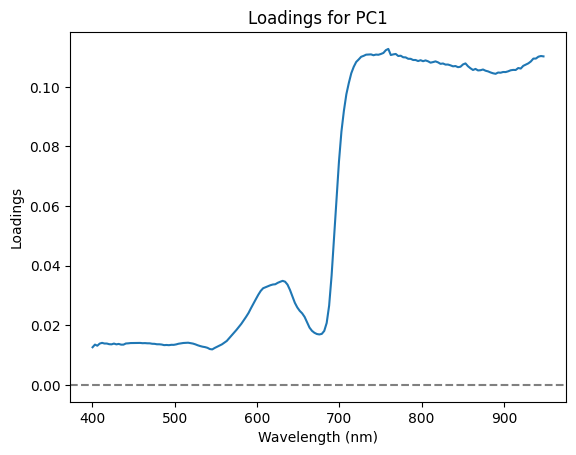

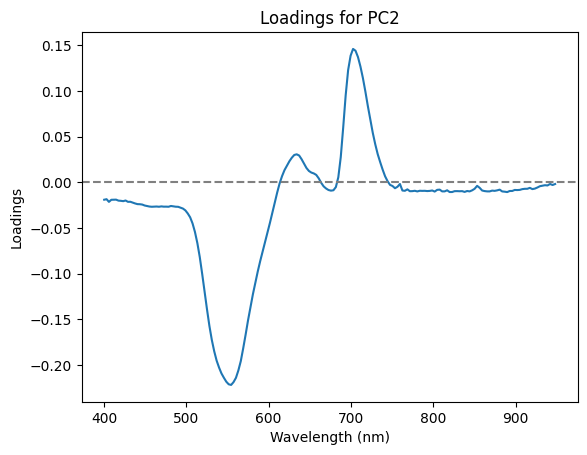

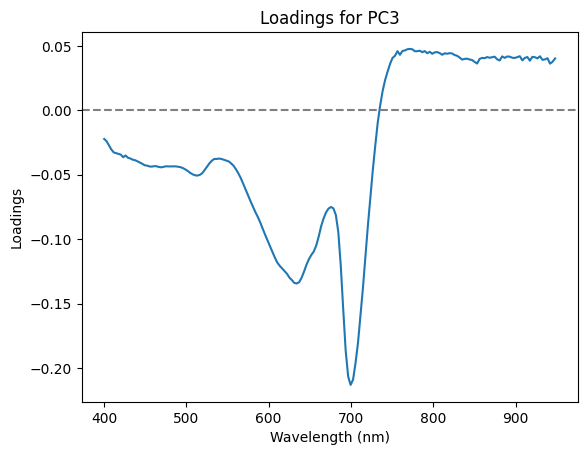

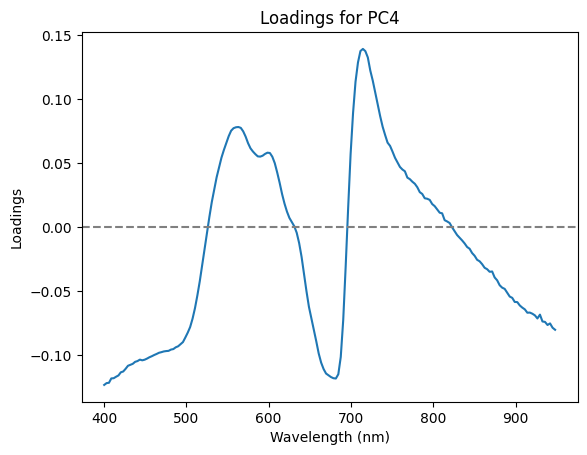

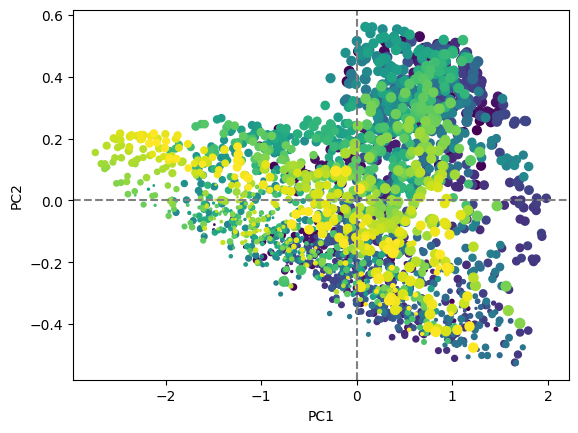

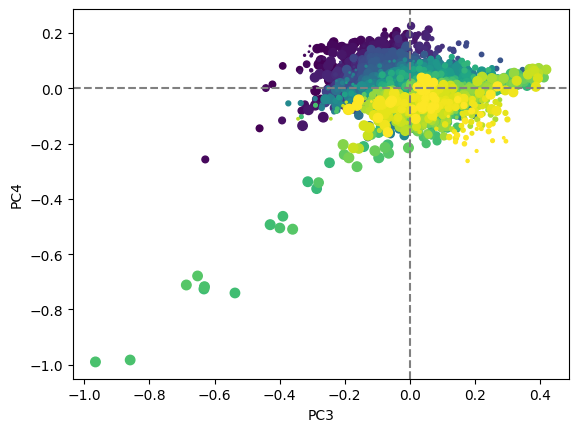

In [20]:
visualize_hdr_dat("/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked_trim400-950.dat",
                  "/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked_trim400-950.hdr")

Metadatos encontrados:
dict_keys(['description', 'samples', 'lines', 'bands', 'header offset', 'file type', 'data type', 'interleave', 'sensor type', 'byte order', 'default bands', 'latitude', 'longitude', 'acquisition date', 'errors', 'binning', 'tint', 'fps', 'wavelength'])
178


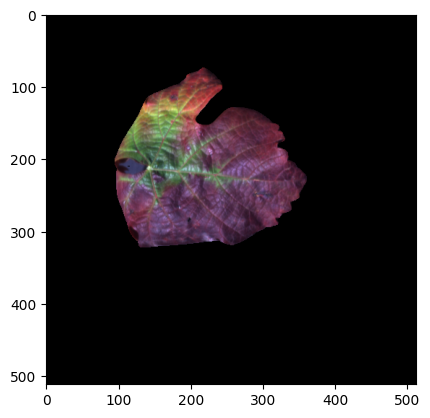

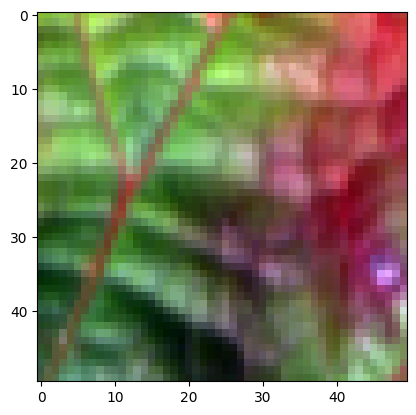

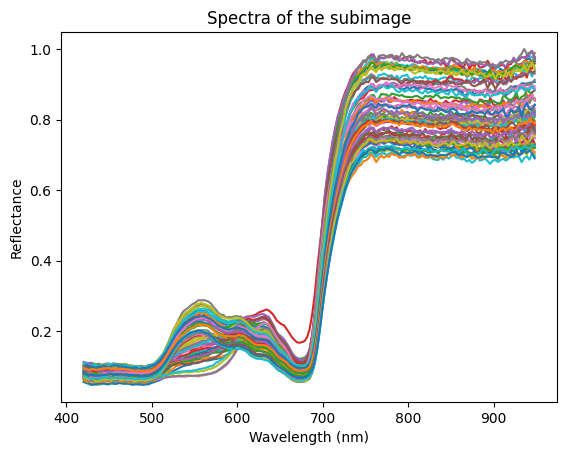

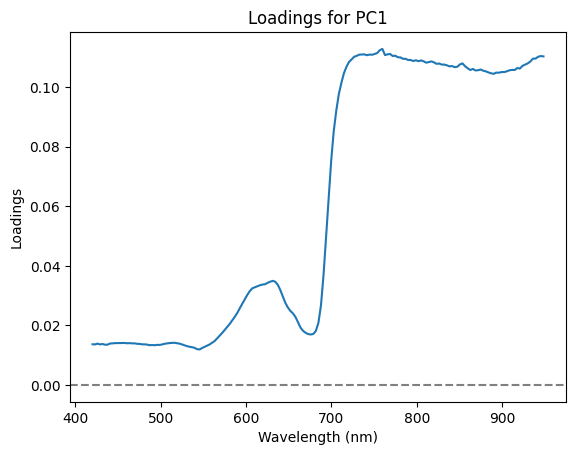

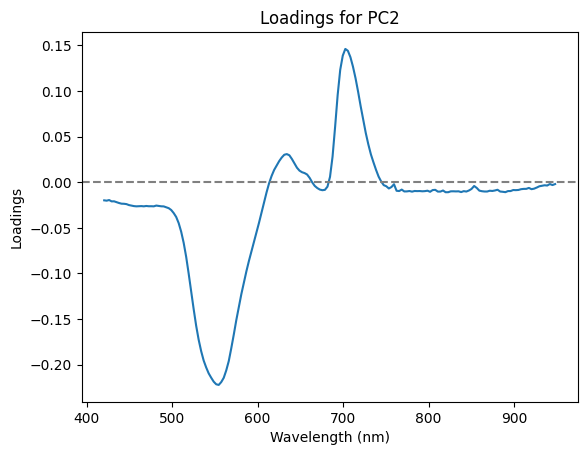

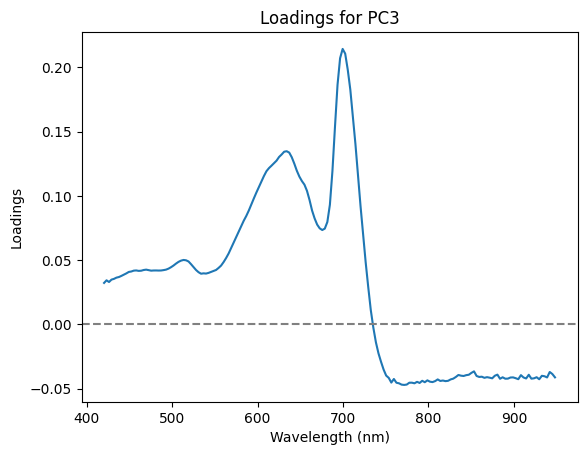

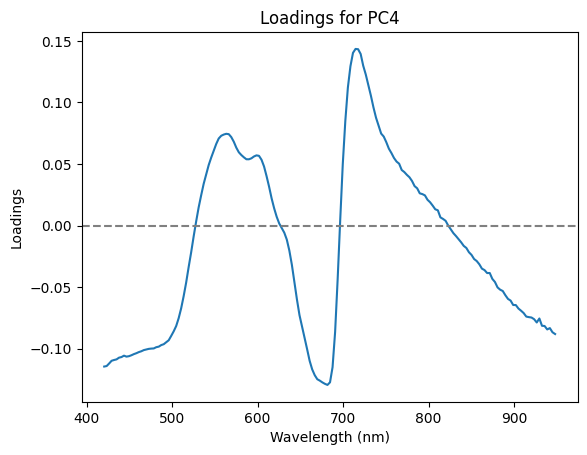

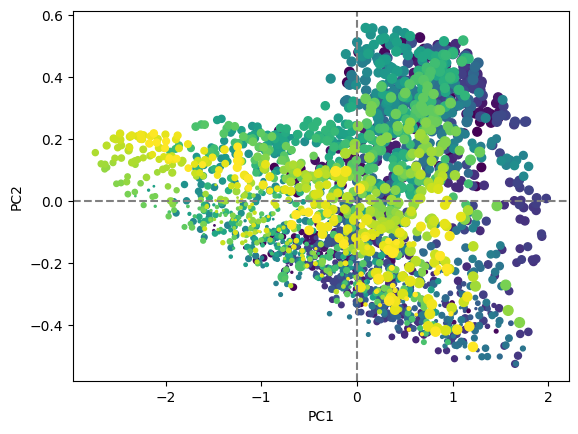

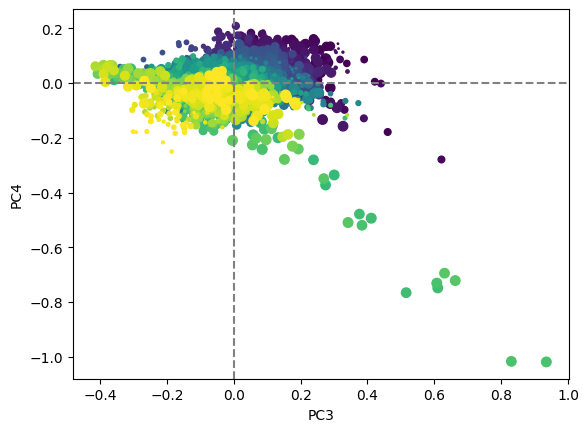

In [22]:
visualize_hdr_dat("/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked_trim420-950.dat",
                  "/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked_trim420-950.hdr")

Metadatos encontrados:
dict_keys(['description', 'samples', 'lines', 'bands', 'header offset', 'file type', 'data type', 'interleave', 'sensor type', 'byte order', 'default bands', 'latitude', 'longitude', 'acquisition date', 'errors', 'binning', 'tint', 'fps', 'wavelength'])
101


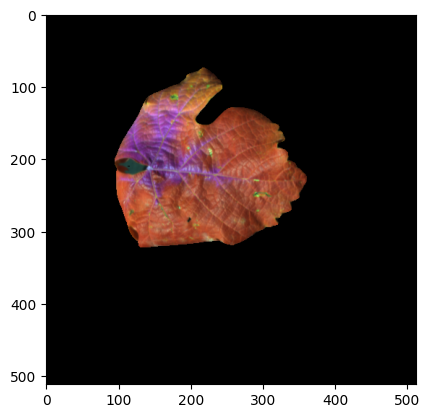

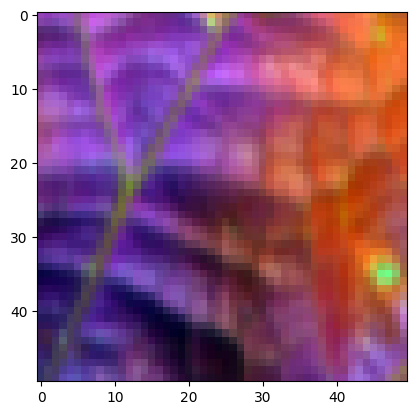

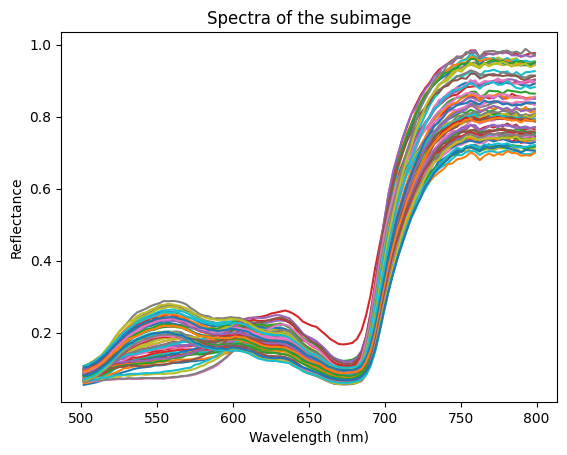

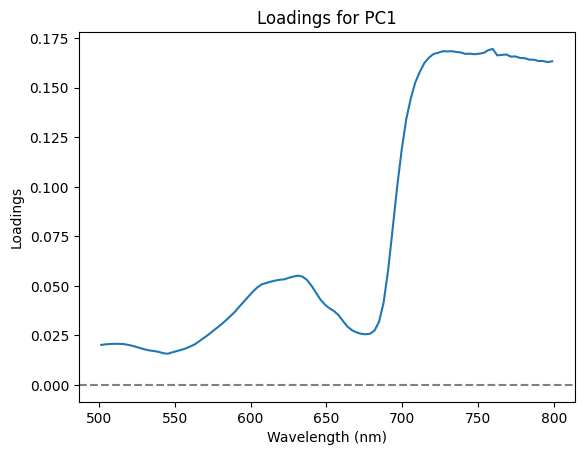

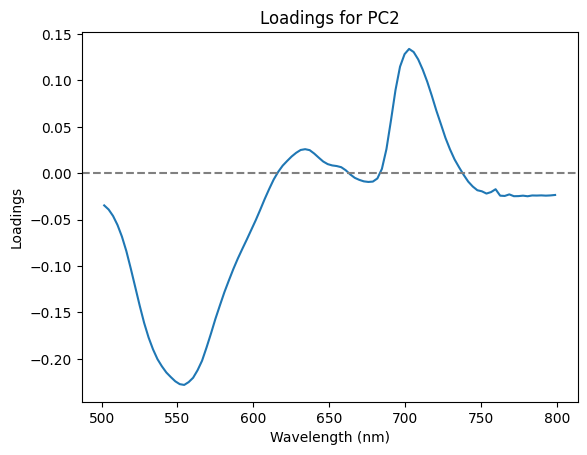

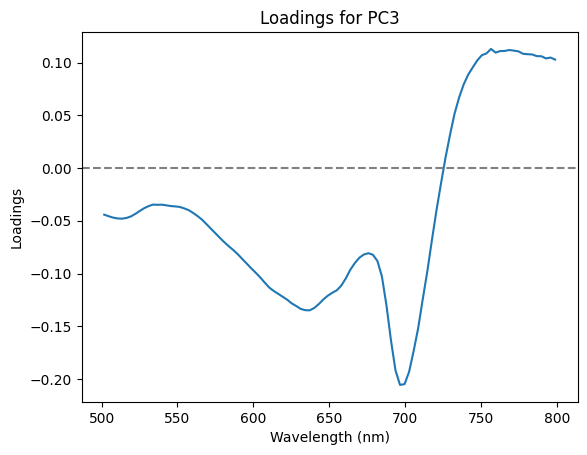

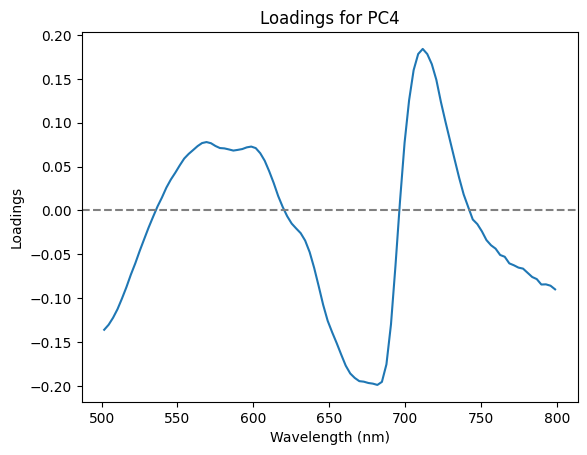

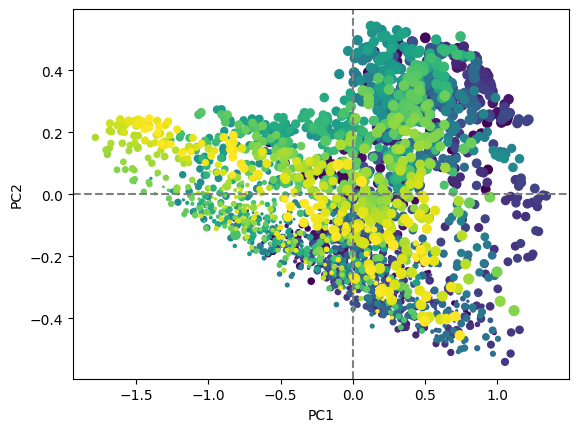

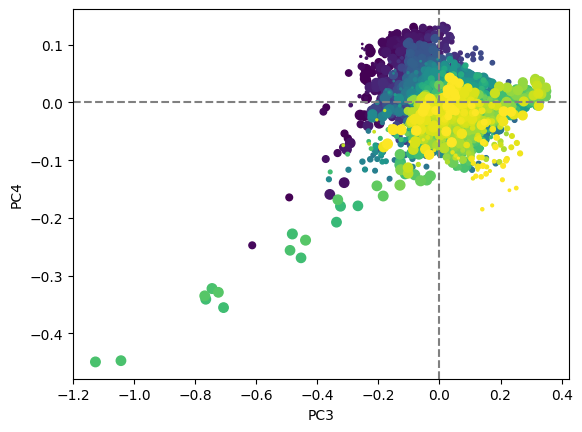

In [24]:
visualize_hdr_dat("/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked_trim500-800.dat",
                  "/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked_trim500-800.hdr")

Metadatos encontrados:
dict_keys(['description', 'samples', 'lines', 'bands', 'header offset', 'file type', 'data type', 'interleave', 'sensor type', 'byte order', 'default bands', 'latitude', 'longitude', 'acquisition date', 'errors', 'binning', 'tint', 'fps', 'wavelength'])
204


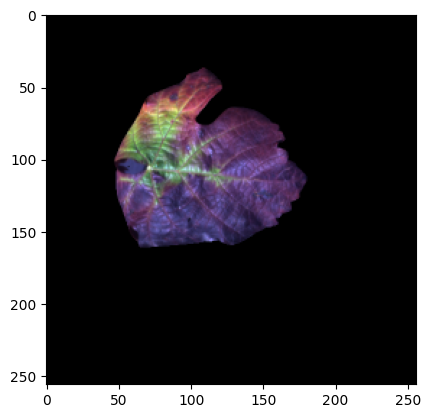

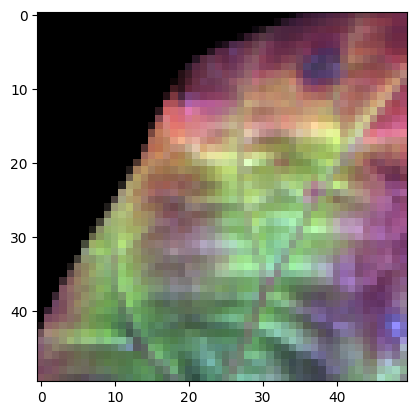

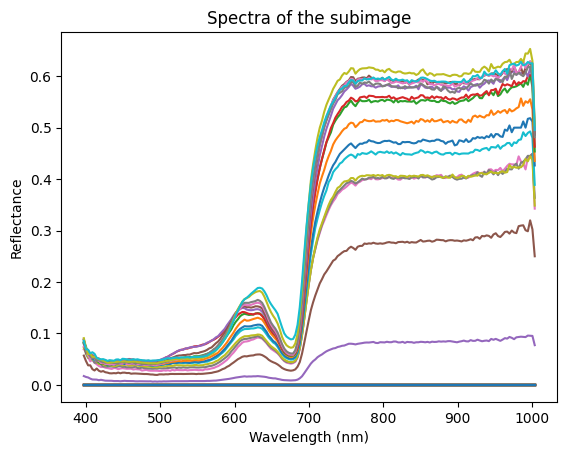

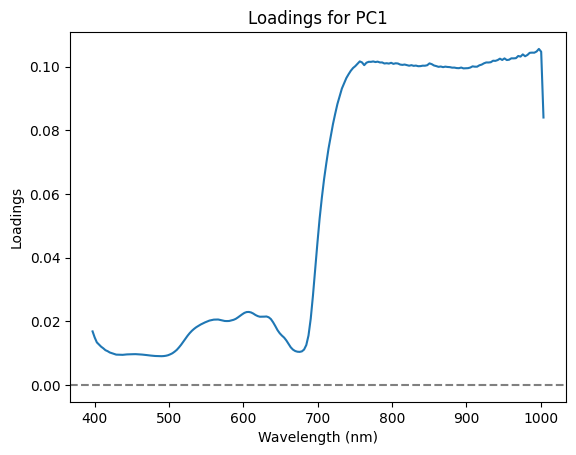

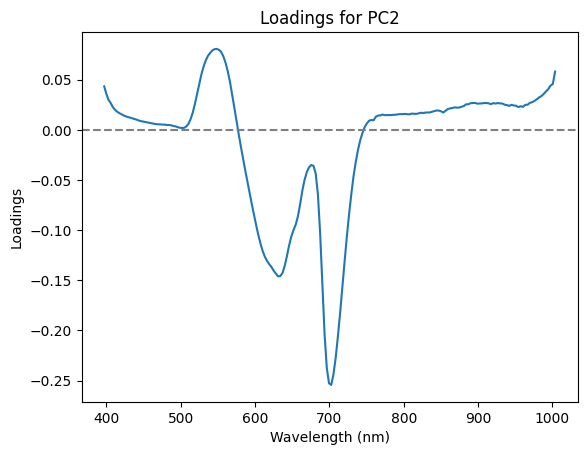

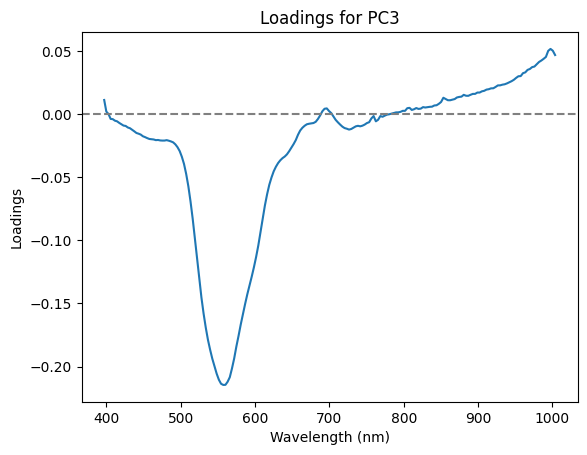

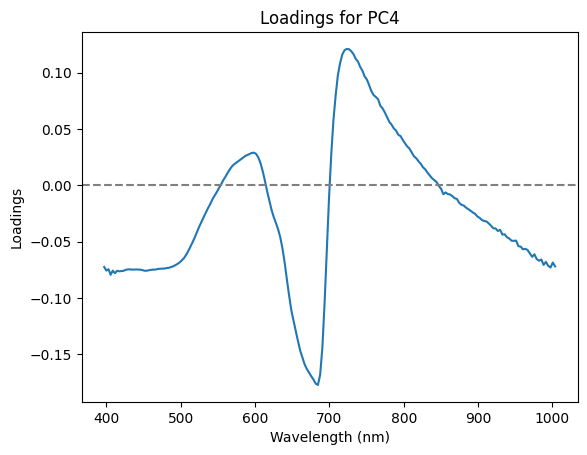

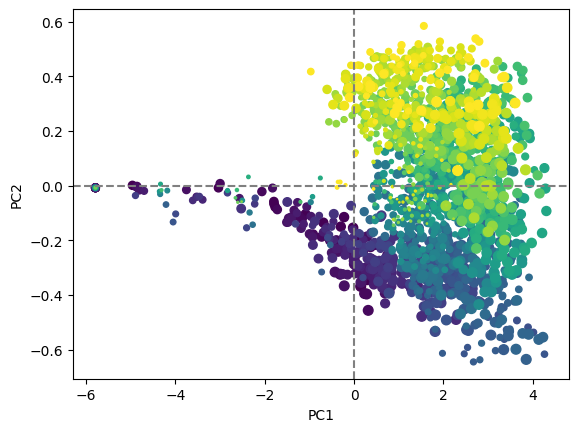

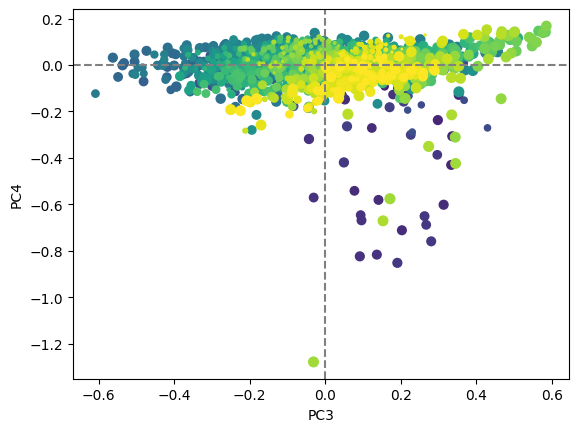

In [ ]:
visualize_hdr_dat_ds2("/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked_ds2.dat",
                      "/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked_ds2.hdr")

Metadatos encontrados:
dict_keys(['description', 'samples', 'lines', 'bands', 'header offset', 'file type', 'data type', 'interleave', 'sensor type', 'byte order', 'default bands', 'latitude', 'longitude', 'acquisition date', 'errors', 'binning', 'tint', 'fps', 'wavelength'])
204
(2500, 204)


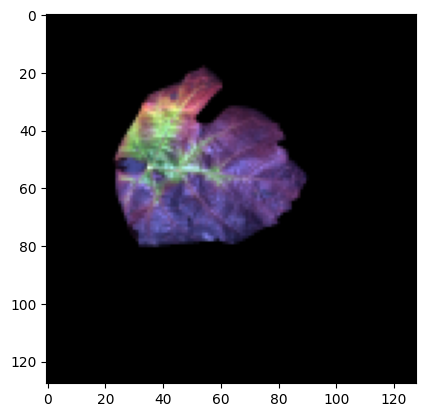

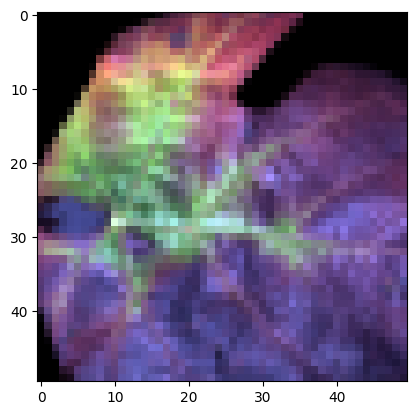

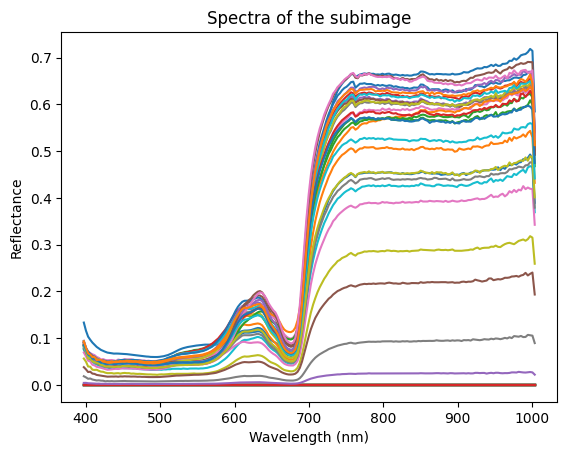

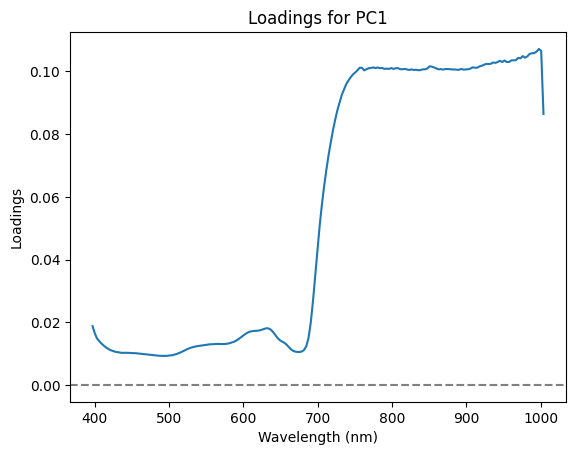

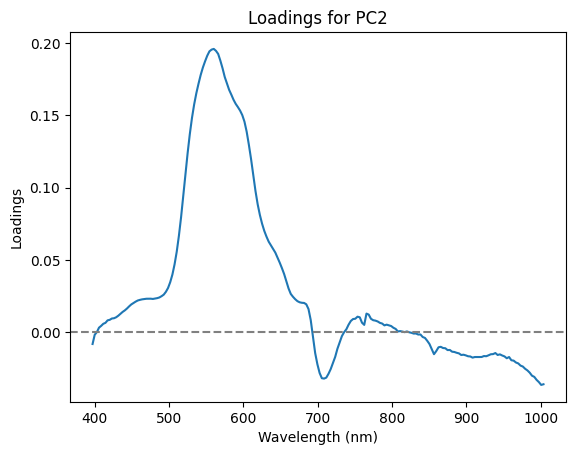

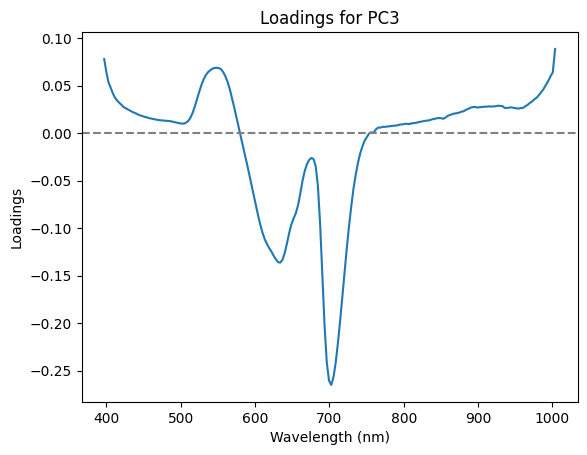

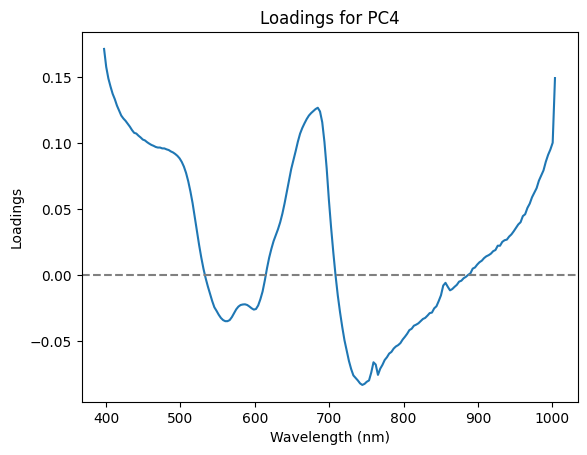

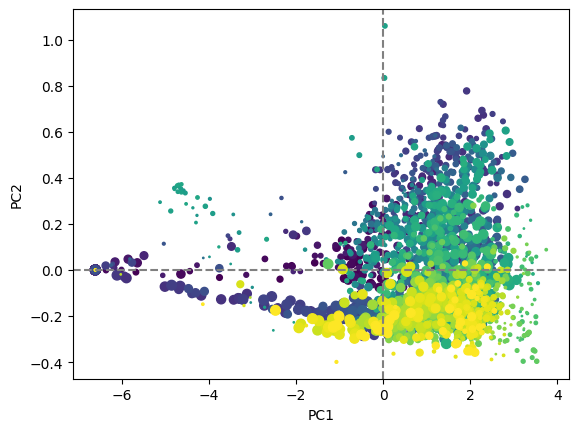

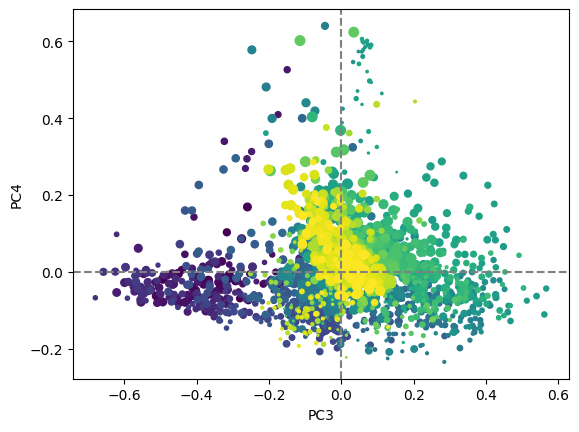

In [34]:
visualize_hdr_dat_ds4("/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked_ds4.dat",
                  "/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked_ds4.hdr")

In [37]:
# -*- coding: utf-8 -*-
"""
Extract valid hyperspectral reflectance data (pixel spectra) into CSV
for later processing (e.g. Genetic Algorithm input).
"""
import os
import pandas as pd

def extract_reflectance_to_csv(datfile, hdrfile, output_csv='reflectance_data.csv', zero_threshold=1e-6):
    # --- Load image ---
    img = envi.open(hdrfile, datfile)
    cube = img.load()  # shape: (lines, samples, bands)
    lines, samples, bands = cube.shape
    print(f"Loaded cube: {lines}x{samples} pixels, {bands} bands")

    # --- Extract wavelengths ---
    try:
        wavelengths = [float(w) for w in img.metadata['wavelength']]
    except KeyError:
        wavelengths = list(range(bands))
        print("⚠️ No 'wavelength' found in metadata; using band indices.")

    # --- Reshape to (num_pixels, bands) ---
    spectra = cube.reshape(lines * samples, bands)

    # --- Remove black/empty/NaN spectra ---
    mask_valid = np.logical_and(
        ~np.isnan(spectra).any(axis=1),
        np.mean(spectra, axis=1) > zero_threshold
    )
    valid_spectra = spectra[mask_valid]

    print(f"Valid pixels kept: {valid_spectra.shape[0]} / {lines * samples}")

    # --- Build DataFrame ---
    df = pd.DataFrame(valid_spectra, columns=[f"{w:.2f}" for w in wavelengths])

    # Optionally, add pixel coordinates
    if 'default bands' in img.metadata:
        coords = np.argwhere(mask_valid.reshape(lines, samples))
        df.insert(0, 'y', coords[:, 0])
        df.insert(1, 'x', coords[:, 1])

    # --- Save to CSV ---
    os.makedirs('Exported', exist_ok=True)
    out_path = os.path.join('Exported', output_csv)
    df.to_csv(out_path, index=False)
    print(f"✅ Saved reflectance data to: {out_path}")

    return df

# Example usage:



In [38]:
df = extract_reflectance_to_csv(
    datfile="/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked_ds4.dat",
    hdrfile="/Users/dylanjitton/Documents/project_plantDisease/dataverse_files/Dataset/Data/2020-09-10_005/results/leaf_segmented_masked_ds4.hdr",
    output_csv="reflectance_valid.csv"
)

Loaded cube: 128x128 pixels, 204 bands
Valid pixels kept: 2888 / 16384
✅ Saved reflectance data to: Exported/reflectance_valid.csv
